In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
llm = ChatOpenAI(
    model="gpt-4.1-mini"
)

In [4]:
class ChatState(TypedDict):
    question: str
    answer: str

In [11]:
def LLM_Chat(state: ChatState) -> ChatState:
    query = state['question']

    # write your prompt
    prompt = f"Answer the following question in simple and short:\n{query}"

    response = llm.invoke(prompt)

    answer = response.content

    state["answer"] = answer

    return state

In [12]:
graph = StateGraph(ChatState)

graph.add_node('LLM_Chat', LLM_Chat)

graph.add_edge(START, 'LLM_Chat')
graph.add_edge('LLM_Chat', END)

In [13]:
workflow = graph.compile()

In [14]:
initial_state = {"question": "what is transformer Neural Network?", "answer" : ""}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'what is transformer Neural Network?', 'answer': 'A Transformer Neural Network is a type of model used in AI that processes data by paying attention to important parts. It is especially good at understanding language and sequences, allowing it to translate, summarize, and generate text efficiently.'}


In [15]:
print(final_state['answer'])

A Transformer Neural Network is a type of model used in AI that processes data by paying attention to important parts. It is especially good at understanding language and sequences, allowing it to translate, summarize, and generate text efficiently.


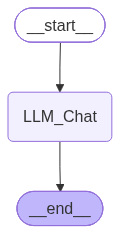

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())